<a href="https://colab.research.google.com/github/202397101/DDI/blob/main/ddi_node500.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 4. Drug–Drug Interaction: 학습 + Inference

순서대로 셀을 실행하세요.  


## Step 1.  dlfb 라이브러리 설치

In [18]:
%cd /content
!rm -rf ./dlfb-clone/
!git clone "https://github.com/deep-learning-for-biology/dlfb.git" dlfb-clone --branch main
%cd dlfb-clone

/content
Cloning into 'dlfb-clone'...
remote: Enumerating objects: 129, done.
remote: Counting objects: 100% (129/129), done.
remote: Compressing objects: 100% (95/95), done.
remote: Total 129 (delta 23), reused 115 (delta 17), pack-reused 0 (from 0)
Receiving objects: 100% (129/129), 63.15 KiB | 3.95 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/dlfb-clone


## Step 2. Install dependencies

In [19]:
%%bash
curl -LsSf https://astral.sh/uv/install.sh | sh && \
export PATH="/root/.local/bin:${PATH}" && \
uv pip compile ./requirements/{base,dlfb,graphs,gpu}.txt \
  --color never \
  --constraint ./requirements/constraints.txt | \
uv pip install -r - --system

installing to /usr/local/bin
  uv
  uvx
everything's installed!


downloading uv 0.11.7 x86_64-unknown-linux-gnu
Resolved 107 packages in 1.99s
Using Python 3.12.13 environment at: /usr
Resolved 107 packages in 1.01s
Prepared 1 package in 1.22s
Uninstalled 2 packages in 53ms
Installed 2 packages in 28ms
 ~ dlfb==0.1.1 (from file:///content/dlfb-clone)
 - numpy==1.26.4
 + numpy==2.1.2


## Step 3. 데이터셋 다운로드

In [20]:
from google.colab import auth

auth.authenticate_user()
# NOTE: exclude models with '--no-models' flag
!dlfb-provision --chapter graphs

Files Downloaded: 100% 567/567 [00:02<00:00, 262.31file/s]


In [ ]:
!pip install numpy==1.26.4
import os
os.kill(os.getpid(),9)

  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 2.1.2
    Uninstalling numpy-2.1.2:
      Successfully uninstalled numpy-2.1.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.25.0+cu128 requires torch==2.10.0, but you have torch 2.11.0+cpu which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.
gradio 5.50.0 requires typer<1.0,>=0.12, but you have typer 0.7.0 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires tqdm>=4.67, but you have tqdm 4.66.5 which is incompatible.
umap-learn 0.5.12 requires s

# 여기서부터 다시 수행!!
## Step 4. 패키지 로드

In [1]:
%env JAX_DISABLE_JIT=False

try:
    import dlfb
except ImportError:
    import site; site.main()
    import dlfb

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
from flax import linen as nn
import optax

from ogb.linkproppred import LinkPropPredDataset
from dlfb.utils.context import assets
from dlfb.graphs.dataset.builder import DatasetBuilder
from dlfb.graphs.model import DdiModel
from dlfb.graphs.train import train, auc_loss
from dlfb.graphs.inspect import plot_learning

print("✅ 모든 패키지 로드 완료")
print(f"numpy: {np.__version__}")

env: JAX_DISABLE_JIT=False
✅ 모든 패키지 로드 완료
numpy: 1.26.4


## Step 5. 약물 이름 테이블 생성

In [2]:
ddi_descriptions = pd.read_csv(
    assets("graphs/datasets/ogbl_ddi/mapping/ddi_description.csv.gz")
)
node_to_dbid_lookup = pd.read_csv(
    assets("graphs/datasets/ogbl_ddi/mapping/nodeidx2drugid.csv.gz")
)

first_drug = ddi_descriptions[["first drug id", "first drug name"]].rename(
    columns={"first drug id": "dbid", "first drug name": "drug_name"}
)
second_drug = ddi_descriptions[["second drug id", "second drug name"]].rename(
    columns={"second drug id": "dbid", "second drug name": "drug_name"}
)
dbid_to_name_lookup = (
    pd.concat([first_drug, second_drug]).drop_duplicates().reset_index(drop=True)
)
drugs_lookup = pd.merge(
    node_to_dbid_lookup.rename(columns={"drug id": "dbid", "node idx": "node_id"}),
    dbid_to_name_lookup, on="dbid", how="inner",
)
print(f"✅ drugs_lookup: {len(drugs_lookup)}개 약물")
drugs_lookup.head()

✅ drugs_lookup: 4267개 약물


,node_id,dbid,drug_name
0,0,DB00001,Lepirudin
1,1,DB00002,Cetuximab
2,2,DB00004,Denileukin diftitox
3,3,DB00005,Etanercept
4,4,DB00006,Bivalirudin


## Step 6. 데이터셋 빌드

In [3]:
node_limit = 500
rng = jax.random.PRNGKey(42)
rng, rng_dataset = jax.random.split(rng, 2)

dataset_splits = DatasetBuilder(path=assets("graphs/datasets")).build(
    node_limit, rng_dataset
)
print(f"✅ 데이터셋 빌드 완료  |  train 노드 수: {dataset_splits['train'].n_nodes}")

/usr/local/lib/python3.12/dist-packages/ogb/linkproppred/dataset.py:67: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  self.graph = torch.load(pre_processed_file_path, 'rb')
/usr/local/lib/python3.12/dist-packages/ogb/linkproppred/dataset.py:138: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  train = torch.load(osp.join(path, 'train.pt'))
/usr/local/lib/python3.12/dist-packages/ogb/linkproppred/dataset.py:139: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  valid = torch.load(osp.join(path, 'valid.pt'))
/usr/local/lib/python3.12/dist-packages/ogb/linkproppred/dataset.py:140: UserWarning

✅ 데이터셋 빌드 완료  |  train 노드 수: 500


## Step 7. 모델 학습
성능 기록 및 시각화: <br>
Hits@20 = (정답이 Top 20 안에 포함된 경우) / 전체 평가 샘플 수 <br>
Positive pair = 실제로 상호작용이 알려진 약물 쌍 → 정답 <br>
Negative pair = 상호작용이 없는 약물 쌍 → 오답

✅ 학습 완료!


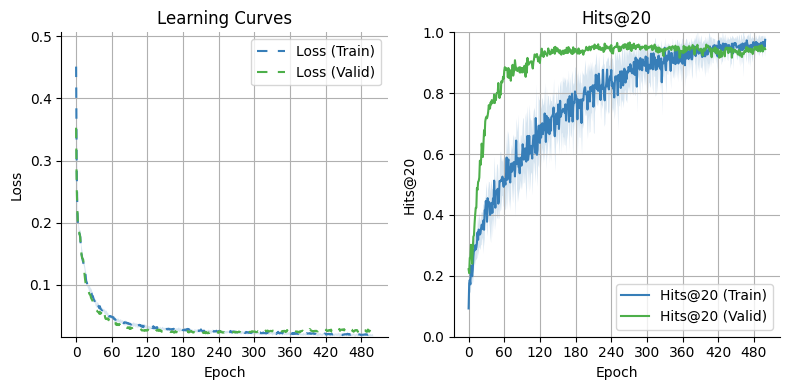

In [4]:
rng, rng_init, rng_train = jax.random.split(rng, 3)

model = DdiModel(
    n_nodes=dataset_splits["train"].n_nodes,
    embedding_dim=512,
    dropout_rate=0.5,
    last_layer_self=True,
    degree_norm=False,
    n_mlp_layers=2,
)

state, metrics = train(
    state=model.create_train_state(
        rng=rng_init,
        dummy_input={
            "graph": dataset_splits["train"].graph,
            "pairs": dataset_splits["train"].pairs.get_dummy_input(),
        },
        tx=optax.adam(0.001),
    ),
    rng=rng_train,
    dataset_splits=dataset_splits,
    num_epochs=50,
    eval_every=1,
    loss_fn=auc_loss,
    norm_loss=True,
    store_path=assets("graphs/models/ddi_model"),
)

plot_learning(metrics)
print("✅ 학습 완료!")

## Step 8. Inference 함수 정의
### 지정된 약물 1개 + 특정 약물 (1쌍)과 상호작용 가능성 높은 약물 TOP 10"


In [10]:
def predict_interaction(state, graph, node_id_a, node_id_b):
    """두 약물 node_id 간 상호작용 확률 반환 (0~1)"""
    pair = jnp.array([[node_id_a, node_id_b]])
    score = state.apply_fn(
        {"params": state.params}, graph, pair,
        is_training=False, is_pred=True,
    )
    return float(nn.sigmoid(score))


def predict_for_drug(state, graph, drug_name, drugs_lookup, top_k=10):
    """특정 약물과 상호작용 가능성 높은 약물 TOP 10"""
    match = drugs_lookup[drugs_lookup["drug_name"].str.contains(drug_name, case=False, na=False)]
    if match.empty:
        print(f"'{drug_name}' 약물을 찾을 수 없습니다.")
        print("사용 가능한 약물 샘플:", drugs_lookup["drug_name"].sample(10).tolist())
        return None

    query_node = int(match.iloc[0]["node_id"])
    query_name  = match.iloc[0]["drug_name"]
    print(f"'{query_name}' (node_id={query_node}) 기준 예측 중...")

    other_nodes = drugs_lookup["node_id"].values
    other_nodes = other_nodes[other_nodes != query_node]
    pairs = np.array([[query_node, n] for n in other_nodes])

    all_probs = []
    for s in range(0, len(pairs), 512):
        scores = state.apply_fn(
            {"params": state.params}, graph,
            jnp.array(pairs[s:s+512]),
            is_training=False, is_pred=True,
        )
        all_probs.append(np.array(nn.sigmoid(scores)))

    name_map = drugs_lookup.set_index("node_id")["drug_name"].to_dict()
    return (
        pd.DataFrame({
            "query_drug":   query_name,
            "target_drug":  [name_map.get(n, f"node_{n}") for n in other_nodes],
            "interaction_prob": np.concatenate(all_probs),
        })
        .sort_values("interaction_prob", ascending=False)
        .reset_index(drop=True)
        .head(top_k)
    )


def predict_top_k_interactions(state, graph, node_ids, drugs_lookup, k=10):
    """약물 집합 중 상호작용 확률 높은 상위 K 쌍"""
    pairs = np.array([
        [node_ids[i], node_ids[j]]
        for i in range(len(node_ids))
        for j in range(i+1, len(node_ids))
    ])
    print(f"총 {len(pairs):,}개 쌍 예측 중...")

    all_probs = []
    for s in range(0, len(pairs), 512):
        scores = state.apply_fn(
            {"params": state.params}, graph,
            jnp.array(pairs[s:s+512]),
            is_training=False, is_pred=True,
        )
        all_probs.append(np.array(nn.sigmoid(scores)))

    name_map = drugs_lookup.set_index("node_id")["drug_name"].to_dict()
    return (
        pd.DataFrame({
            "drug_a": [name_map.get(p[0], f"node_{p[0]}") for p in pairs],
            "drug_b": [name_map.get(p[1], f"node_{p[1]}") for p in pairs],
            "interaction_prob": np.concatenate(all_probs),
        })
        .sort_values("interaction_prob", ascending=False)
        .reset_index(drop=True)
        .head(k)
    )


def check_known_vs_predicted(state, graph, dataset_splits, drugs_lookup, n_samples=10):
    """Test set 실제 label vs 모델 예측 비교"""
    pos = dataset_splits["test"].pairs.pos[:n_samples]
    neg = dataset_splits["test"].pairs.neg[:n_samples]
    all_pairs = np.concatenate([pos, neg], axis=0)
    labels    = np.array([1]*len(pos) + [0]*len(neg))

    probs = np.array(nn.sigmoid(state.apply_fn(
        {"params": state.params}, graph,
        jnp.array(all_pairs),
        is_training=False, is_pred=True,
    )))

    name_map = drugs_lookup.set_index("node_id")["drug_name"].to_dict()
    return pd.DataFrame({
        "drug_a":           [name_map.get(p[0], f"node_{p[0]}") for p in all_pairs],
        "drug_b":           [name_map.get(p[1], f"node_{p[1]}") for p in all_pairs],
        "true_label":       labels,
        "predicted_prob":   probs,
        "predicted_label":  (probs >= 0.5).astype(int),
        "correct":          ((probs >= 0.5).astype(int) == labels),
    })

print("✅ Inference 함수 정의 완료")

## Step 9. 모델 수행

### 특정 약물 기준 TOP 10  

특정 약물 ibuprofen 이 있는지 확인

In [20]:
result = drugs_lookup[drugs_lookup["drug_name"].str.contains("Quinidine", case=False)]
print(result)

      node_id     dbid       drug_name
807       807  DB00908       Quinidine
4218     4218  DB15300  Hydroquinidine


In [21]:
graph = dataset_splits["train"].graph
result_df = predict_for_drug(state, graph, drug_name="Quinidine", drugs_lookup=drugs_lookup, top_k=10)
if result_df is not None:
    display(result_df)

'Quinidine' (node_id=807) 기준 예측 중...


,query_drug,target_drug,interaction_prob
0,Quinidine,Framycetin,0.599138
1,Quinidine,Denileukin diftitox,0.596447
2,Quinidine,Lepirudin,0.596421
3,Quinidine,Capromab pendetide,0.595868
4,Quinidine,Carteolol,0.595691
5,Quinidine,Metixene,0.595367
6,Quinidine,"Antihemophilic factor, human recombinant",0.595119
7,Quinidine,Midodrine,0.594795
8,Quinidine,Fluorometholone,0.594469
9,Quinidine,Hyoscyamine,0.594062


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Ibuprofen 기준 TOP 10 예측
result_df = predict_for_drug(state, graph, drug_name="Ibuprofen",
                             drugs_lookup=drugs_lookup, top_k=10)

if result_df is not None:
    # 그래프 생성
    G = nx.Graph()

    # 중심 노드 추가
    center = result_df["query_drug"].iloc[0]
    G.add_node(center)

    # 엣지 추가 (상호작용 확률을 weight로)
    for _, row in result_df.iterrows():
        G.add_node(row["target_drug"])
        G.add_edge(center, row["target_drug"], weight=row["interaction_prob"])

    # 레이아웃: 중심 약물을 가운데, 나머지를 주변에
    pos = nx.spring_layout(G, seed=42)
    pos[center] = (0, 0)  # Ibuprofen 중앙 고정

    # 엣지 두께 = 상호작용 확률
    weights = [G[u][v]["weight"] * 5 for u, v in G.edges()]

    # 색상: 중심 노드는 빨강, 나머지는 파랑
    node_colors = ["red" if n == center else "grey" for n in G.nodes()]
    node_sizes  = [5000 if n == center else 3000 for n in G.nodes()]

    fig, ax = plt.subplots(figsize=(12, 8))

    # 노드 & 엣지 그리기
    nx.draw_networkx_nodes(G, pos, node_color=node_colors,
                           node_size=node_sizes, ax=ax)
    nx.draw_networkx_edges(G, pos, width=weights,
                           edge_color="gray", alpha=0.6, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=10,
                            font_color="black", ax=ax)

    # 엣지 레이블: 확률값
    edge_labels = {(center, row["target_drug"]): f"{row['interaction_prob']:.3f}"
                   for _, row in result_df.iterrows()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                                 font_size=8, ax=ax)

    ax.set_title(f"{center} DDI network (TOP 10)", fontsize=15, fontweight="bold")
    ax.axis("off")
    plt.tight_layout()
    plt.show()